## Geocalibration ZL048 and ZR048

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

In [3]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl0 + left_fl1 * fmc
  elif (data_["cam"][idx][1] == "R"):
    return right_fl0 + right_fl1 * fmc

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

In [4]:
f_str = "048"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)
outlier_removed = False

# parse data into left and right cam
zl, zr = get_zl_zr(f_str, data_all)

# parse cahvor vectors
parse_cahvor(zl)
parse_cahvor(zr)

# outlier removal
zl_outlier_idx = [5,6,7,8,9,10,11,21,22,23,24,25,26,27,28,29,32,33,34,35,36,37]
zr_outlier_idx = []
if not outlier_removed:
  zl = zl.drop(zl_outlier_idx).reset_index(drop=True)
  zr = zr.drop(zr_outlier_idx).reset_index(drop=True)
  outlier_removed = True

print('-'*75)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

---------------------------------------------------------------------------
Number of data points for zl048:	16
Number of data points for zr048:	248


## Rotation $R^m_c$ fitting

Here we assume the the rotation $R^r_{r'}$ we computed from ZL034 and ZR034 are correct and we will use the [Kabsch algorithm](https://en.wikipedia.org/wiki/Kabsch_algorithm) to solve for a single $R^r_c$ for each ZL034 and ZR034. Knowing $R^r_c$ we can then find $R^m_c = (R^{r'}_m)^T (R^r_{r'})^T R^r_c $ 

In [34]:
# here we fit for ZL048

r_frame = []
c_frame = []

for i in range(zl.shape[0]):
  # get Hr
  hr = get_H_r_data(i, zl)
  r_frame.extend([list(hr[:,0]), list(hr[:,1]), list(hr[:,2])])

  # compute Hc
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  c_frame.append([fl+b1, b2, cx])
  c_frame.append([0, fl, cy])
  c_frame.append([0, 0, 1])

r_frame = np.array(r_frame)
c_frame = np.array(c_frame)


# align the vectors
rot_rc, rssd, sens = R.align_vectors(r_frame, c_frame, return_sensitivity=True)

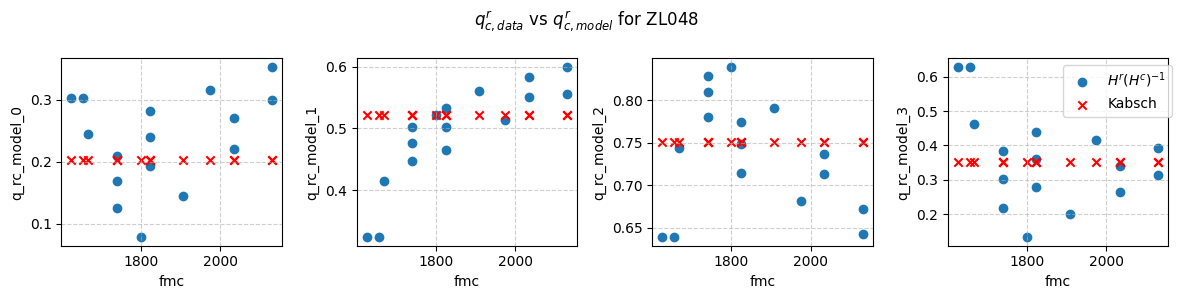

In [35]:
q_rc_data_left, q_rc_model_left = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
q_rc = rot_rc.as_quat(canonical=True)
for i in range(zl.shape[0]):
  # compute q_rc from data
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zl)
  q_rc_data_left.append(R.from_matrix(Hr @ Hc_inv).as_quat(canonical=True))

# plot 
fig, ax = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
  ax[i].scatter(zl["fmc"], [q[i] for q in q_rc_data_left], label="$H^r(H^c)^{-1}$")
  ax[i].scatter(zl["fmc"], [q_rc[i] for _ in q_rc_data_left], marker='x', color='red',
                label="Kabsch")
  ax[i].set_xlabel(f"fmc")
  ax[i].set_ylabel(f"q_rc_model_{i}")
  ax[i].grid(linestyle="--", alpha=0.6)

ax[3].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$q^r_{c,data}$ vs $q^r_{c,model}$ for ZL048")
fig.tight_layout()



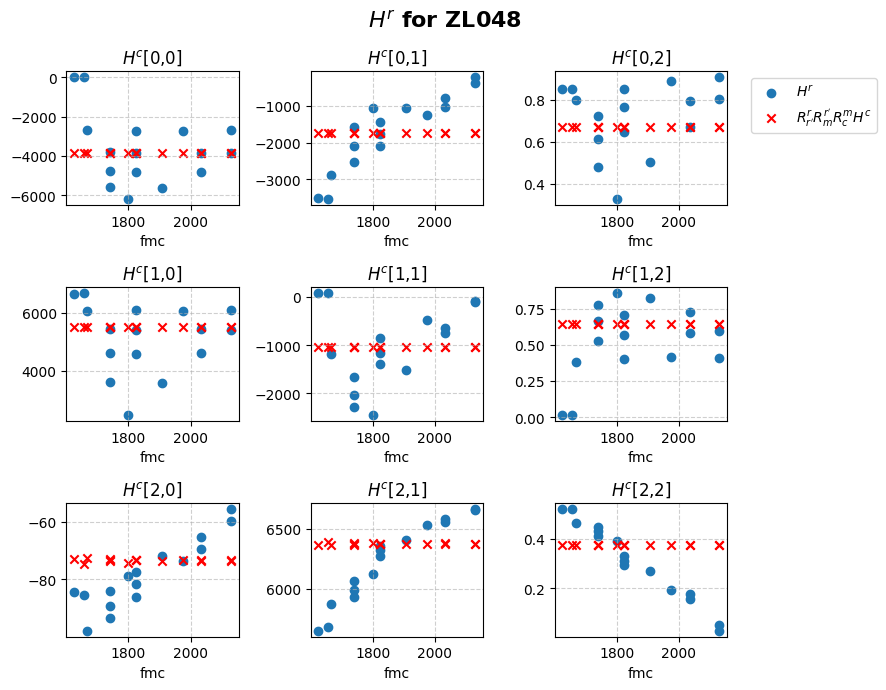

In [36]:
hr_data_left, hr_model_left = [], []

for i in range(zl.shape[0]):
  # compute Hr from data
  hr_data_left.append(get_H_r_data(i, zl))

  # compute Hc from model
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]

  hr_model_left.append(rot_rc.as_matrix() @ hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_model_left], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()

In [37]:
# here we fit for ZR048

r_frame = []
c_frame = []

for i in range(zr.shape[0]):
  # get Hr
  hr = get_H_r_data(i, zr)
  r_frame.extend([list(hr[:,0]), list(hr[:,1]), list(hr[:,2])])

  # compute Hc
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  c_frame.append([fl+b1, b2, cx])
  c_frame.append([0, fl, cy])
  c_frame.append([0, 0, 1])

r_frame = np.array(r_frame)
c_frame = np.array(c_frame)


# align the vectors
rot_rc, rssd, sens = R.align_vectors(r_frame, c_frame, return_sensitivity=True)

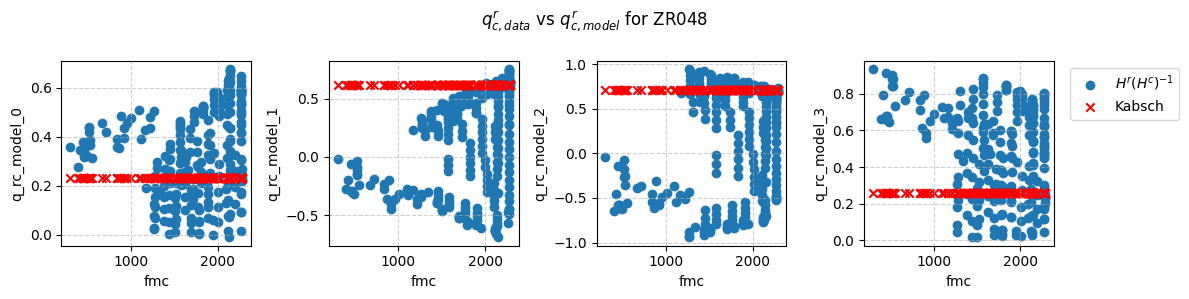

In [38]:
q_rc_data_right, q_rc_model_right = [], []

rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
q_rc = rot_rc.as_quat(canonical=True)
for i in range(zr.shape[0]):
  # compute q_rc from data
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zr)
  q_rc_data_right.append(R.from_matrix(Hr @ Hc_inv).as_quat(canonical=True))

# plot 
fig, ax = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
  ax[i].scatter(zr["fmc"], [q[i] for q in q_rc_data_right], label="$H^r(H^c)^{-1}$")
  ax[i].scatter(zr["fmc"], [q_rc[i] for _ in q_rc_data_right], marker='x', color='red',
                label="Kabsch")
  ax[i].set_xlabel(f"fmc")
  ax[i].set_ylabel(f"q_rc_model_{i}")
  ax[i].grid(linestyle="--", alpha=0.6)

ax[3].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$q^r_{c,data}$ vs $q^r_{c,model}$ for ZR048")
fig.tight_layout()

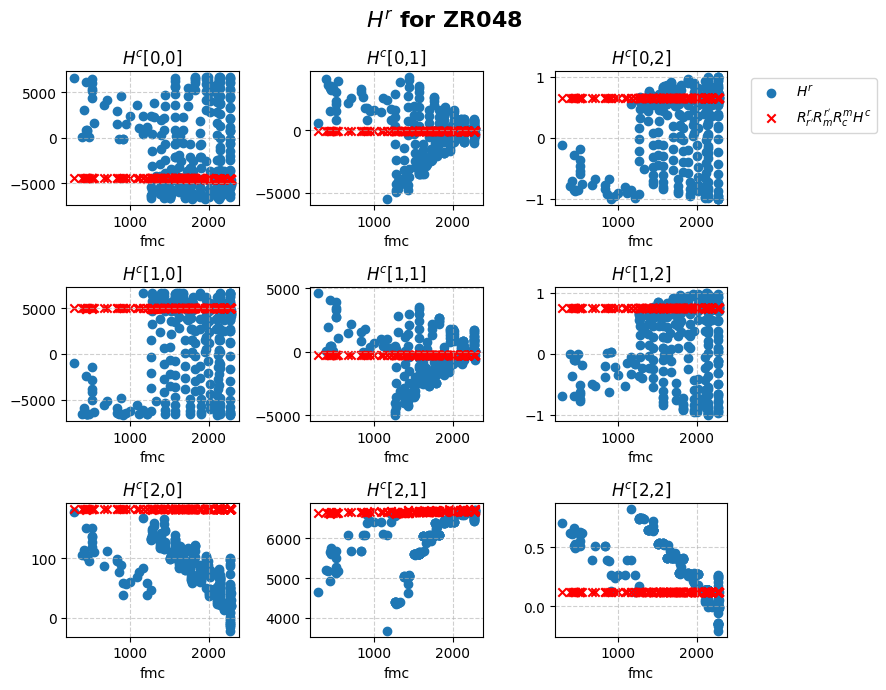

In [39]:
hr_data_right, hr_model_right = [], []
R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

for i in range(zr.shape[0]):
  # compute Hr from data
  hr_data_right.append(get_H_r_data(i, zr))

  # compute Hc from model
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]]

  hr_model_right.append(rot_rc.as_matrix() @ hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_data_right], label="$H^r$")
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_model_right], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()

Here we assume the correctness of $R^r_{r'}$ and we use the Kabsch algorithm to find $R^m_c$

In [12]:
# here we fit for ZL048
R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

m_frame = []
c_frame = []
for i in range(zl.shape[0]):
  # get Hr
  hr = get_H_r_data(i, zl)
  R_rpm = get_R_rpm(i, zl)
  hm = (R_rrp @ R_rpm).T @ hr
  m_frame.extend([list(hm[:,0]), list(hm[:,1]), list(hm[:,2])])

  # compute Hc
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  c_frame.append([fl+b1, b2, cx])
  c_frame.append([0, fl, cy])
  c_frame.append([0, 0, 1])

r_frame = np.array(m_frame)
c_frame = np.array(c_frame)


# align the vectors
rot_mc, rssd, sens = R.align_vectors(m_frame, c_frame, return_sensitivity=True)

In [13]:
print(rot_mc.as_quat(canonical=True))

[0.4365611  0.51377002 0.55644727 0.48561426]


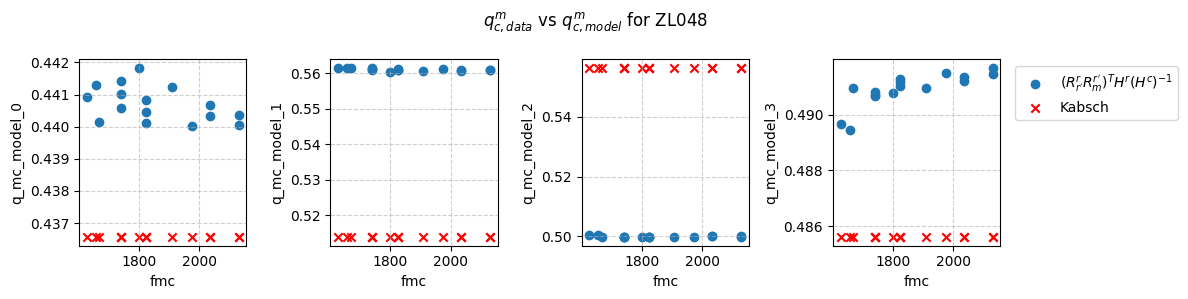

In [7]:
q_mc_data_left = []
q_mc = rot_mc.as_quat(canonical=True)
R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
for i in range(zl.shape[0]):
  # compute q_mc from data
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zl)
  R_rpm = get_R_rpm(i, zl)
  rot_mc_data = (R_rrp @ R_rpm).T @ Hr @ Hc_inv
  q_mc_data_left.append(R.from_matrix(rot_mc_data).as_quat(canonical=True))

# plot 
fig, ax = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
  ax[i].scatter(zl["fmc"], [q[i] for q in q_mc_data_left], label="$(R^r_{r'}R^{r'}_m)^T H^r(H^c)^{-1}$")
  ax[i].scatter(zl["fmc"], [q_mc[i] for _ in q_mc_data_left], marker='x', color='red',
                label="Kabsch")
  ax[i].set_xlabel(f"fmc")
  ax[i].set_ylabel(f"q_mc_model_{i}")
  ax[i].grid(linestyle="--", alpha=0.6)

ax[3].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$q^m_{c,data}$ vs $q^m_{c,model}$ for ZL048")
fig.tight_layout()

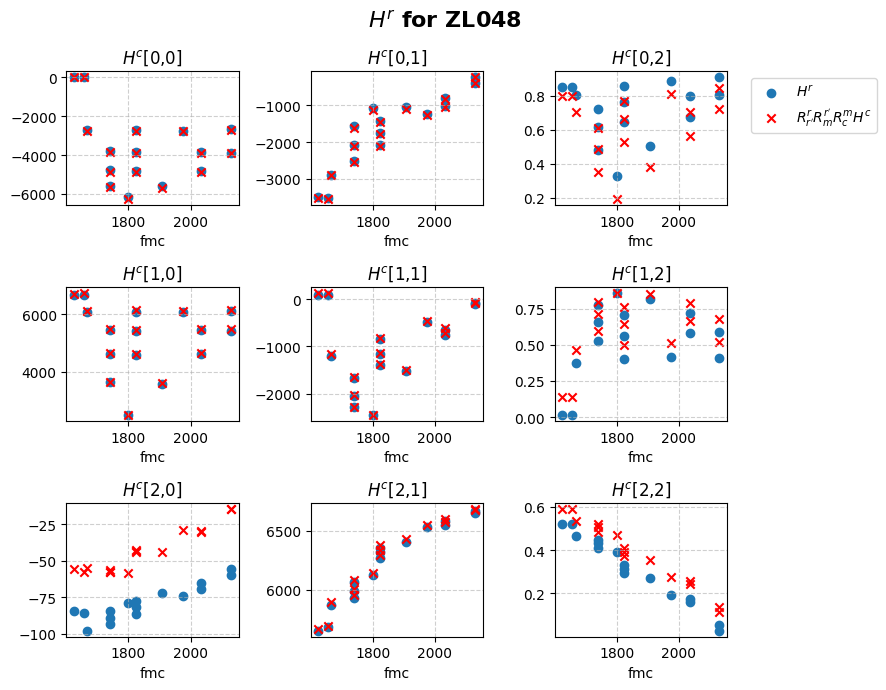

In [8]:
hr_data_left, hr_model_left = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
R_mc = rot_mc.as_matrix()
for i in range(zl.shape[0]):
  # compute Hr from data
  hr_data_left.append(get_H_r_data(i, zl))

  # compute Hc from model
  fl, b1, b2, cx, cy = zl[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  R_rpm = get_R_rpm(i, zl)
  hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
    ax[i,j].scatter(zl["fmc"], [hc[i][j] for hc in hr_model_left], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZL048", fontsize=16, fontweight="bold")
fig.tight_layout()

In [9]:
# here we fit for ZL048
R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()

m_frame = []
c_frame = []
for i in range(zr.shape[0]):
  # get Hr
  hr = get_H_r_data(i, zr)
  R_rpm = get_R_rpm(i, zr)
  hm = (R_rrp @ R_rpm).T @ hr
  m_frame.extend([list(hm[:,0]), list(hm[:,1]), list(hm[:,2])])

  # compute Hc
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  c_frame.append([fl+b1, b2, cx])
  c_frame.append([0, fl, cy])
  c_frame.append([0, 0, 1])

m_frame = np.array(m_frame)
c_frame = np.array(c_frame)


# align the vectors
rot_mc, rssd, sens = R.align_vectors(m_frame, c_frame, return_sensitivity=True)

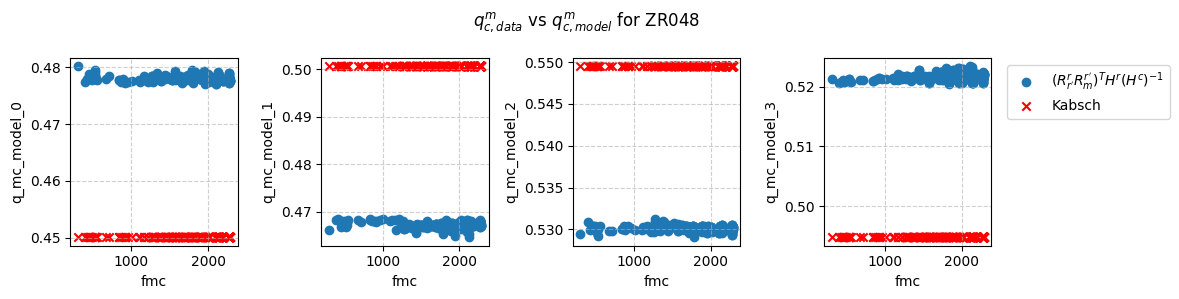

In [10]:
q_mc_data_right = []
q_mc = rot_mc.as_quat(canonical=True)
R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
for i in range(zr.shape[0]):
  # compute q_mc from data
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  Hc_inv = np.array([[1/(fl+b1), 0, 0],
                     [-b2/(fl*(fl+b1)), 1/fl, 0],
                     [cy*b2/(fl*(fl+b1)) - cx/(fl+b1), -cy/fl, 1]])
  Hr = get_H_r_data(i, zr)
  R_rpm = get_R_rpm(i, zr)
  rot_mc_data = (R_rrp @ R_rpm).T @ Hr @ Hc_inv
  q_mc_data_right.append(R.from_matrix(rot_mc_data).as_quat(canonical=True))

# plot 
fig, ax = plt.subplots(1, 4, figsize=(12,3))
for i in range(4):
  ax[i].scatter(zr["fmc"], [q[i] for q in q_mc_data_right], label="$(R^r_{r'}R^{r'}_m)^T H^r(H^c)^{-1}$")
  ax[i].scatter(zr["fmc"], [q_mc[i] for _ in q_mc_data_right], marker='x', color='red',
                label="Kabsch")
  ax[i].set_xlabel(f"fmc")
  ax[i].set_ylabel(f"q_mc_model_{i}")
  ax[i].grid(linestyle="--", alpha=0.6)

ax[3].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("$q^m_{c,data}$ vs $q^m_{c,model}$ for ZR048")
fig.tight_layout()

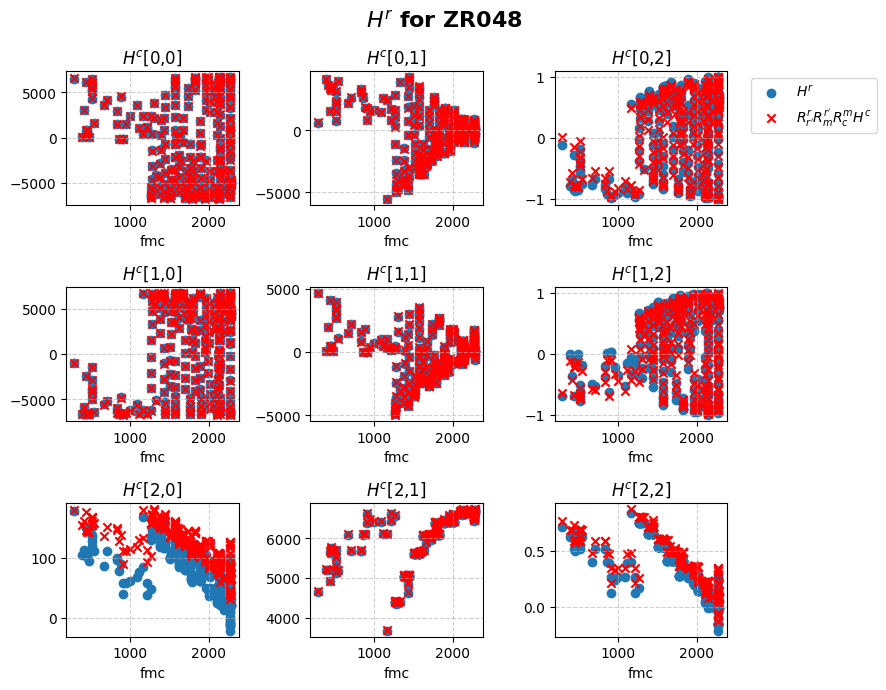

In [11]:
hr_data_right, hr_model_right = [], []

R_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]).as_matrix()
R_mc = rot_mc.as_matrix()
for i in range(zr.shape[0]):
  # compute Hr from data
  hr_data_right.append(get_H_r_data(i, zr))

  # compute Hc from model
  fl, b1, b2, cx, cy = zr[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
  hc = [[fl+b1, 0, 0],
             [b2, fl, 0],
             [cx, cy, 1]]
  R_rpm = get_R_rpm(i, zr)
  hr_model_right.append(R_rrp @ R_rpm @ R_mc @ hc)

# plot
fig, ax = plt.subplots(3, 3, figsize=(9,7))
for i in range(3):
  for j in range(3):
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_data_right], label="$H^r$")
    ax[i,j].scatter(zr["fmc"], [hc[i][j] for hc in hr_model_right], 
                    marker="x", color="red",
                    label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
    ax[i,j].set_xlabel("fmc")
    ax[i,j].set_title(f"$H^c$[{i},{j}]")
    ax[i,j].grid(linestyle="--", alpha=0.6)

ax[0,2].legend(bbox_to_anchor=(1.1, 1))
fig.suptitle("$H^r$ for ZR048", fontsize=16, fontweight="bold")
fig.tight_layout()